In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

DATASET = Path(
    "/content/drive/MyDrive/RPS_merged_4class_yolov8"
)
DATA_YAML = DATASET / "data.yaml"

print("Dataset exists:", DATASET.exists())
print("YAML exists:", DATA_YAML.exists())
print(DATA_YAML.read_text())

print("Train:", len(list((DATASET / "train/images").glob("*"))))
print("Valid:", len(list((DATASET / "valid/images").glob("*"))))
print("Test:", len(list((DATASET / "test/images").glob("*"))))

Dataset exists: True
YAML exists: True
path: .
train: train/images
val: valid/images
test: test/images

nc: 4
names: [paper, rock, scissors, unknown]

Train: 6725
Valid: 596
Test: 316


In [3]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.1 MB/s eta 0:00:00


In [6]:
!nvidia-smi

Sat Aug  8 20:38:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             27W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU: Tesla T4


In [9]:
from pathlib import Path

DATASET = Path("/content/drive/MyDrive/RPS_merged_4class_yolov8")

COLAB_YAML = Path("/content/rps_data.yaml")

COLAB_YAML.write_text(f"""
path: {DATASET}
train: train/images
val: valid/images
test: test/images

nc: 4
names:
  0: paper
  1: rock
  2: scissors
  3: unknown
""".strip())

print(COLAB_YAML.read_text())

path: /content/drive/MyDrive/RPS_merged_4class_yolov8
train: train/images
val: valid/images
test: test/images

nc: 4
names:
  0: paper
  1: rock
  2: scissors
  3: unknown


In [10]:
print("Train exists:", (DATASET / "train/images").exists())
print("Valid exists:", (DATASET / "valid/images").exists())
print("Test exists:", (DATASET / "test/images").exists())

Train exists: True
Valid exists: True
Test exists: True


In [12]:
!rm -rf /content/RPS_merged_4class_yolov8

!cp -r \
"/content/drive/MyDrive/RPS_merged_4class_yolov8" \
"/content/RPS_merged_4class_yolov8"

In [13]:
from pathlib import Path

DATASET = Path("/content/RPS_merged_4class_yolov8")
COLAB_YAML = Path("/content/rps_data.yaml")

COLAB_YAML.write_text(f"""
path: {DATASET}
train: train/images
val: valid/images
test: test/images

nc: 4
names:
  0: paper
  1: rock
  2: scissors
  3: unknown
""".strip())

print(COLAB_YAML.read_text())

path: /content/RPS_merged_4class_yolov8
train: train/images
val: valid/images
test: test/images

nc: 4
names:
  0: paper
  1: rock
  2: scissors
  3: unknown


In [14]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(COLAB_YAML),
    epochs=60,
    imgsz=640,
    batch=-1,
    device=0,
    patience=15,
    workers=2,
    project="/content/drive/MyDrive/RPS_training",
    name="rps_merged_4class",
    exist_ok=True,
    plots=True
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rps_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rps_merged_4class, nbs=64, nms=False, o

In [15]:
from pathlib import Path

BEST_MODEL = Path(
    "/content/drive/MyDrive/RPS_training/"
    "rps_merged_4class/weights/best.pt"
)

print("Model exists:", BEST_MODEL.exists())
print("Model size:", round(BEST_MODEL.stat().st_size / 1_000_000, 2), "MB")

Model exists: True
Model size: 6.25 MB


In [16]:
metrics = model.val(
    data="/content/rps_data.yaml",
    split="test",
    imgsz=640,
    device=0,
    plots=True
)

print("mAP@50:", metrics.box.map50)
print("mAP@50–95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 884.3±322.0 MB/s, size: 27.2 KB)
val: Scanning /content/RPS_merged_4class_yolov8/test/labels... 316 images, 130 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 316/316 2.8Kit/s 0.1s
val: New cache created: /content/RPS_merged_4class_yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 5.5it/s 3.6s
                   all        316        204      0.866      0.907      0.927      0.735
                 paper         72         72      0.874      0.869      0.887      0.652
                  rock         59         65      0.883      0.908      0.944      0.765
              scissors         66         67       0.84      0.944      0.951      0.786
Speed: 1.9ms preprocess, 4.1ms inference, 0.0ms los

In [17]:
!mkdir -p "/content/drive/MyDrive/RPS_training/test_evaluation"
!cp -r "/content/runs/detect/val/"* \
"/content/drive/MyDrive/RPS_training/test_evaluation/"

In [18]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-08-09 at 1.44.27 AM.jpeg to WhatsApp Image 2026-08-09 at 1.44.27 AM.jpeg



0: 640x480 1 paper, 5.8ms
Speed: 2.7ms preprocess, 5.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


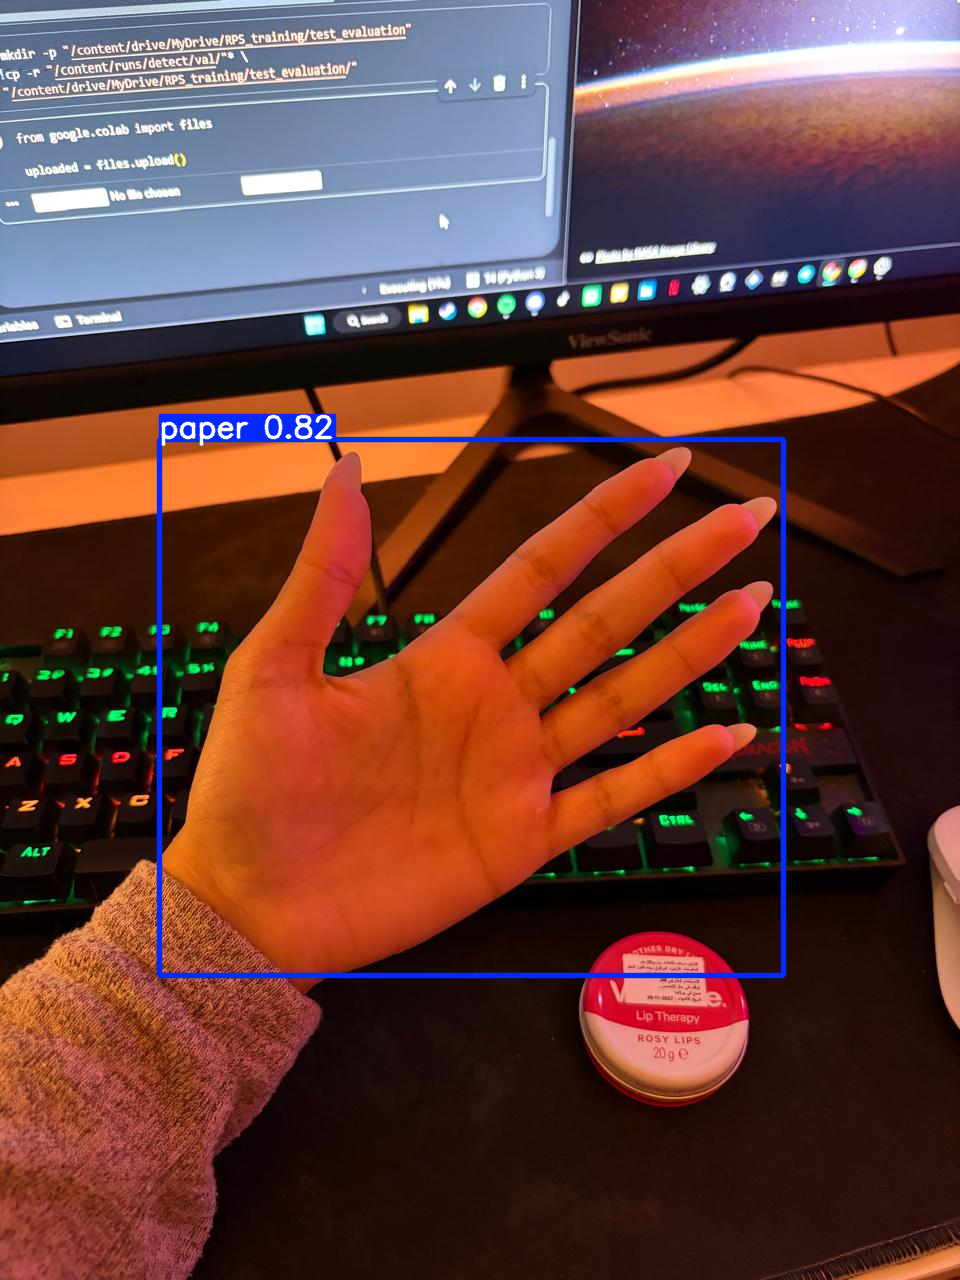

In [19]:
from PIL import Image
from IPython.display import display

predictions = model.predict(
    source=list(uploaded.keys()),
    conf=0.25,
    imgsz=640
)

for result in predictions:
    plotted = result.plot()
    display(Image.fromarray(plotted[:, :, ::-1]))

In [20]:
!pip install -q --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.8 MB/s eta 0:00:00


In [21]:
from ultralytics import YOLO

BEST_MODEL = (
    "/content/drive/MyDrive/RPS_training/"
    "rps_merged_4class/weights/best.pt"
)

model = YOLO(BEST_MODEL)

print(model.names)

{0: 'paper', 1: 'rock', 2: 'scissors', 3: 'unknown'}


In [27]:
import cv2
import gradio as gr

def detect_live(frame, confidence):
    if frame is None:
        return None

    # Gradio supplies RGB; OpenCV/YOLO uses BGR arrays.
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    result = model.predict(
        source=frame_bgr,
        conf=confidence,
        imgsz=640,
        device=0,
        verbose=False
    )[0]

    annotated_bgr = result.plot()
    annotated_rgb = cv2.cvtColor(
        annotated_bgr,
        cv2.COLOR_BGR2RGB
    )

    return annotated_rgb


with gr.Blocks(title="Live Rock Paper Scissors Detection") as demo:
    gr.Markdown(
        """
        # Live Rock–Paper–Scissors Detection
        Classes: **Paper, Rock, Scissors, Unknown**
        """
    )

    confidence = gr.Slider(
        minimum=0.10,
        maximum=0.90,
        value=0.25,
        step=0.05,
        label="Confidence threshold"
    )

    with gr.Row():
        webcam = gr.Image(
            sources=["webcam"],
            type="numpy",
            streaming=True,
            label="Live camera"
        )

        output = gr.Image(
            type="numpy",
            label="Live detections"
        )

    webcam.stream(
        fn=detect_live,
        inputs=[webcam, confidence],
        outputs=output,
        stream_every=0.15,
        time_limit=300,
        concurrency_limit=1
    )

demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8df51c631708588be3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8df51c631708588be3.gradio.live


In [28]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/RPS_training/"
    "rps_merged_4class/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>